# 🌍 Air Quality Prediction using CNN + BiLSTM + Attention
### Sustainable AI — Predicting PM2.5 Pollution Levels

**Architecture:** 1D-CNN → BiLSTM → Bahdanau Attention → Dense  
**Target:** PM2.5 (µg/m³) — 24-hour ahead forecast  
**Dataset:** UCI Beijing PM2.5 (publicly available, no sign-up required)

| Component | Detail |
|---|---|
| Framework | TensorFlow 2.x / Keras |
| Task | Multi-step time-series regression |
| Input window | 48 hours |
| Forecast horizon | 24 hours |
| Sustainability Goal | Early warning system for hazardous air quality |

## 1. Install & Import Dependencies

In [5]:
!pip install -q tensorflow pandas numpy scikit-learn matplotlib seaborn plotly joblib

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import joblib
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Load Dataset

In [7]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00381/PRSA_data_2010.1.1-2014.12.31.csv'
df = pd.read_csv(url)
print(f'Shape: {df.shape}')
df.head()

Shape: (43824, 13)


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


## 3. Preprocessing & Feature Engineering

In [8]:
def preprocess(df):
    df = df.copy()
    df.drop(columns=['No'], inplace=True)
    df['datetime'] = pd.to_datetime(df[['year','month','day','hour']])
    df.set_index('datetime', inplace=True)
    df.drop(columns=['year','month','day','hour'], inplace=True)

    le = LabelEncoder()
    df['cbwd'] = le.fit_transform(df['cbwd'].astype(str))
    df.fillna(method='ffill', inplace=True)
    df.dropna(inplace=True)

    # Cyclical time features
    df['hour_sin']  = np.sin(2 * np.pi * df.index.hour  / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df.index.hour  / 24)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

    # Lag & rolling features
    df['pm25_lag1']   = df['pm2.5'].shift(1)
    df['pm25_lag3']   = df['pm2.5'].shift(3)
    df['pm25_lag6']   = df['pm2.5'].shift(6)
    df['pm25_roll24'] = df['pm2.5'].rolling(24).mean()
    df.dropna(inplace=True)
    return df

df_clean = preprocess(df)
print(f'Clean shape: {df_clean.shape}')
df_clean.describe()

Clean shape: (43777, 16)


,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir,hour_sin,hour_cos,month_sin,month_cos,pm25_lag1,pm25_lag3,pm25_lag6,pm25_roll24
count,43777.000000,43777.000000,43777.000000,43777.000000,43777.000000,43777.000000,43777.000000,43777.000000,43777.000000,4.377700e+04,4.377700e+04,4.377700e+04,43777.000000,43777.000000,43777.000000,43777.000000
mean,97.758252,1.833954,12.468260,1016.442995,1.663339,23.894498,0.052470,0.195125,-0.000006,2.206469e-05,-5.445955e-03,-3.029587e-03,97.761541,97.768394,97.778788,97.795467
std,91.414595,14.431064,12.189945,10.272232,0.938246,50.034431,0.760262,1.416612,0.707108,7.071219e-01,7.059259e-01,7.082744e-01,91.414100,91.413074,91.411669,77.287352
min,0.000000,-40.000000,-19.000000,991.000000,0.000000,0.450000,0.000000,0.000000,-1.000000,-1.000000e+00,-1.000000e+00,-1.000000e+00,0.000000,0.000000,0.000000,2.916667
25%,29.000000,-10.000000,2.000000,1008.000000,1.000000,1.790000,0.000000,0.000000,-0.707107,-7.071068e-01,-8.660254e-01,-8.660254e-01,29.000000,29.000000,29.000000,41.583333
50%,72.000000,2.000000,14.000000,1016.000000,2.000000,5.370000,0.000000,0.000000,0.000000,6.123234e-17,-2.449294e-16,-1.836970e-16,72.000000,72.000000,72.000000,78.416667
75%,136.000000,15.000000,23.000000,1025.000000,2.000000,21.910000,0.000000,0.000000,0.707107,7.071068e-01,5.000000e-01,8.660254e-01,136.000000,136.000000,136.000000,130.875000
max,994.000000,28.000000,42.000000,1046.000000,3.000000,585.600000,27.000000,36.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,994.000000,994.000000,994.000000,646.333333


## 4. Exploratory Data Analysis

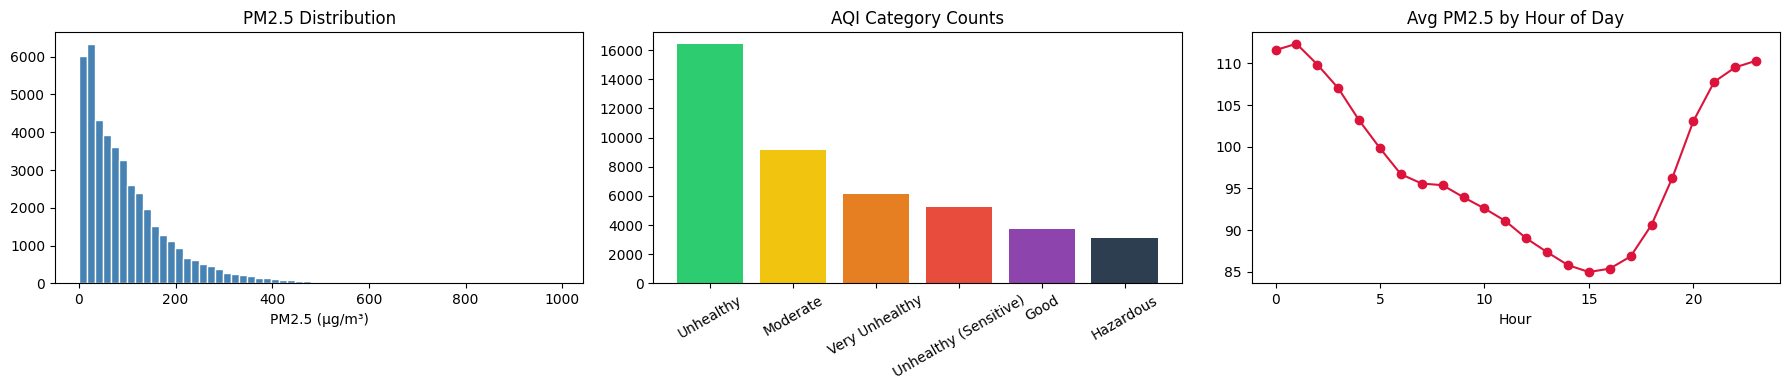

In [9]:
def aqi_category(pm):
    if pm <= 12:     return 'Good'
    elif pm <= 35.4: return 'Moderate'
    elif pm <= 55.4: return 'Unhealthy (Sensitive)'
    elif pm <= 150.4:return 'Unhealthy'
    elif pm <= 250.4:return 'Very Unhealthy'
    else:            return 'Hazardous'

df_clean['AQI_Cat'] = df_clean['pm2.5'].apply(aqi_category)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df_clean['pm2.5'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('PM2.5 Distribution')
axes[0].set_xlabel('PM2.5 (µg/m³)')

cat_counts = df_clean['AQI_Cat'].value_counts()
palette = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#2c3e50']
axes[1].bar(cat_counts.index, cat_counts.values, color=palette[:len(cat_counts)])
axes[1].set_title('AQI Category Counts')
axes[1].tick_params(axis='x', rotation=30)

hourly = df_clean.groupby(df_clean.index.hour)['pm2.5'].mean()
axes[2].plot(hourly.index, hourly.values, 'o-', color='crimson')
axes[2].set_title('Avg PM2.5 by Hour of Day')
axes[2].set_xlabel('Hour')

plt.tight_layout()
plt.show()

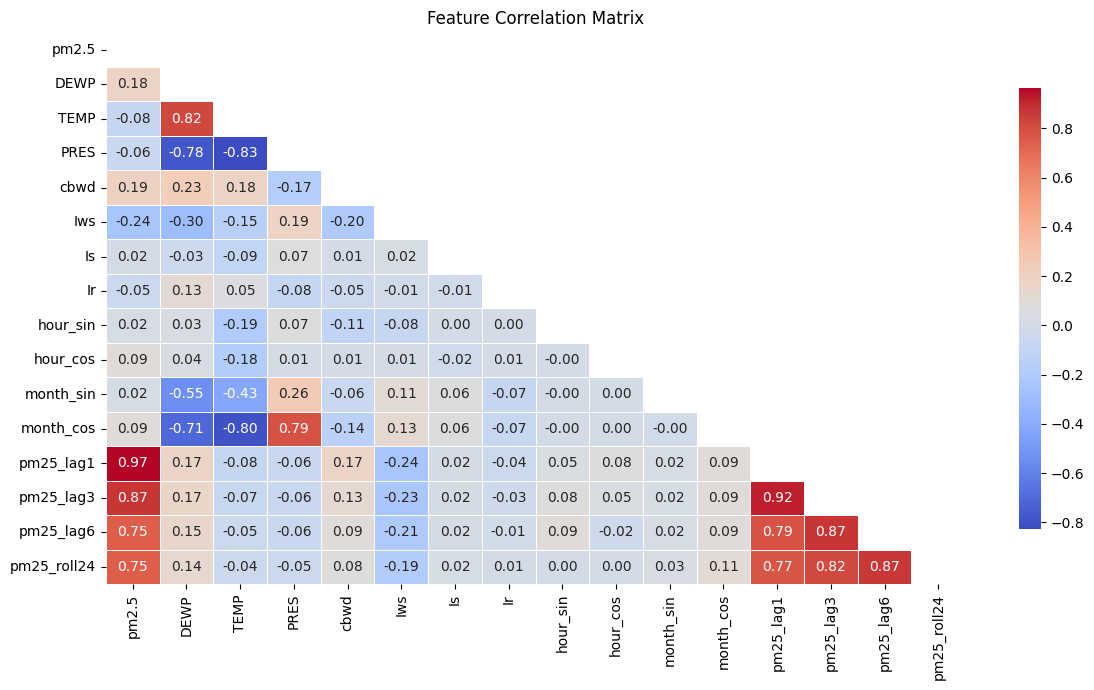

In [10]:
plt.figure(figsize=(12, 7))
num_cols = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'shrink':0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [11]:
sample = df_clean['pm2.5'].resample('D').mean().reset_index()
fig = px.line(sample, x='datetime', y='pm2.5',
              title='Daily Average PM2.5 (2010-2014)',
              color_discrete_sequence=['#e74c3c'])
fig.add_hline(y=35.4,  line_dash='dash', line_color='orange',
              annotation_text='Moderate threshold')
fig.add_hline(y=150.4, line_dash='dash', line_color='red',
              annotation_text='Unhealthy threshold')
fig.update_layout(height=420)
fig.show()

## 5. Build Sequences

In [12]:
LOOKBACK   = 48
FORECAST   = 24
TARGET_COL = 'pm2.5'

FEATURE_COLS = [c for c in df_clean.select_dtypes(include=[np.number]).columns
                if c != 'AQI_Cat']

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_clean[FEATURE_COLS])
target_idx  = FEATURE_COLS.index(TARGET_COL)

def build_sequences(data, lookback, forecast, t_idx):
    X, y = [], []
    for i in range(len(data) - lookback - forecast):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback:i+lookback+forecast, t_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = build_sequences(data_scaled, LOOKBACK, FORECAST, target_idx)
print(f'X: {X.shape}  y: {y.shape}')

n    = len(X)
n_tr = int(n * 0.70)
n_vl = int(n * 0.15)
X_train,y_train = X[:n_tr], y[:n_tr]
X_val,  y_val   = X[n_tr:n_tr+n_vl], y[n_tr:n_tr+n_vl]
X_test, y_test  = X[n_tr+n_vl:], y[n_tr+n_vl:]
print(f'Train:{X_train.shape[0]}  Val:{X_val.shape[0]}  Test:{X_test.shape[0]}')

X: (43705, 48, 16)  y: (43705, 24)
Train:30593  Val:6555  Test:6557


## 6. Model — 1D CNN + BiLSTM + Bahdanau Attention

In [13]:
class BahdanauAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = layers.Dense(units)
        self.W2 = layers.Dense(units)
        self.V  = layers.Dense(1)

    def call(self, query, values):
        q   = tf.expand_dims(query, 1)
        score   = self.V(tf.nn.tanh(self.W1(values) + self.W2(q)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * values, axis=1)
        return context, weights


def build_model(input_shape, forecast_horizon,
                cnn_filters=64, kernel_size=3,
                lstm_units=128, attn_units=64, dropout=0.3):

    inp = keras.Input(shape=input_shape)

    # CNN block
    x = layers.Conv1D(cnn_filters,   kernel_size, padding='causal', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(cnn_filters*2, kernel_size, padding='causal', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # BiLSTM block
    x = layers.Bidirectional(
    layers.LSTM(
        lstm_units,
        return_sequences=True,
        activation="tanh",
        recurrent_activation="sigmoid",
        recurrent_dropout=0.0,
        unroll=False,
        use_bias=True
    )
)(x)
    x = layers.Dropout(dropout)(x)
    lstm_out, fh, fc, bh, bc = layers.Bidirectional(
    layers.LSTM(
        lstm_units,
        return_sequences=True,
        return_state=True,
        activation="tanh",
        recurrent_activation="sigmoid",
        recurrent_dropout=0.0,
        unroll=False,
        use_bias=True
    )
)(x)
    state_h = layers.Concatenate()([fh, bh])

    # Attention
    context, _ = BahdanauAttention(attn_units)(state_h, lstm_out)

    # Output
    x = layers.Concatenate()([context, state_h])
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout/2)(x)
    x = layers.Dense(64,  activation='relu')(x)
    out = layers.Dense(forecast_horizon)(x)

    return Model(inp, out, name='AirQuality_CNN_BiLSTM_Attn')


model = build_model((LOOKBACK, len(FEATURE_COLS)), FORECAST)
model.summary(line_length=80)

Model: "AirQuality_CNN_BiLSTM_Attn"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 48, 16)    │           0 │ -                  │
│ (InputLayer)          │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1d (Conv1D)       │ (None, 48, 64)    │       3,136 │ input_layer[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 48, 64)    │         256 │ conv1d[0][0]       │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv1d_1 (Conv1D)     │ (None, 48, 128)   │      24,704 │ batch_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 48, 128)   │         512 │ conv1d_1[0][0]     │
│ (BatchNormalization)  │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout (Dropout)     │ (None, 48, 128)   │           0 │ batch_normalizati… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bidirectional         │ (None, 48, 256)   │     263,168 │ dropout[0][0]      │
│ (Bidirectional)       │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_1 (Dropout)   │ (None, 48, 256)   │           0 │ bidirectional[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bidirectional_1       │ [(None, 48, 256), │     394,240 │ dropout_1[0][0]    │
│ (Bidirectional)       │ (None, 128),      │             │                    │
│                       │ (None, 128),      │             │                    │
│                       │ (None, 128),      │             │                    │
│                       │ (None, 128)]      │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate           │ (None, 256)       │           0 │ bidirectional_1[0… │
│ (Concatenate)         │                   │             │ bidirectional_1[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ bahdanau_attention    │ [(None, 256),     │      32,961 │ concatenate[0][0], │
│ (BahdanauAttention)   │ (None, 48, 1)]    │             │ bidirectional_1[0… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ concatenate_1         │ (None, 512)       │           0 │ bahdanau_attentio… │
│ (Concatenate)         │                   │             │ concatenate[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_3 (Dense)       │ (None, 128)       │      65,664 │ concatenate_1[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_2 (Dropout)   │ (None, 128)       │           0 │ dense_3[0][0]      │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_4 (Dense)       │ (None, 64)        │       8,256 │ dropout_2[0][0]    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dense_5 (Dense)       │ (None, 24)        │       1,560 │ dense_4[0][0]      │
└───────────────────────┴───────────────────┴─────────────┴────────────────────┘

 Total params: 794,457 (3.03 MB)

 Trainable params: 794,073 (3.03 MB)

 Non-trainable params: 384 (1.50 KB)

## 7. Compile & Train

In [14]:
model.compile(
    optimizer = Adam(learning_rate=1e-3, clipnorm=1.0),
    loss      = Huber(delta=1.0),
    metrics   = ['mae']
)

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint('best_aq_model.h5', monitor='val_loss',
                               save_best_only=True, verbose=0)
]

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 60,
    batch_size      = 256,
    callbacks       = cbs,
    verbose         = 1
)

Epoch 1/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0053 - mae: 0.0714

120/120 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - loss: 0.0036 - mae: 0.0589 - val_loss: 0.0053 - val_mae: 0.0682 - learning_rate: 0.0010
Epoch 2/60
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0024 - mae: 0.0497

120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0023 - mae: 0.0482 - val_loss: 0.0044 - val_mae: 0.0650 - learning_rate: 0.0010
Epoch 3/60
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0019 - mae: 0.0441

120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0018 - mae: 0.0430 - val_loss: 0.0037 - val_mae: 0.0642 - learning_rate: 0.0010
Epoch 4/60
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0016 - mae: 0.0401

120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0015 - mae: 0.0388 - val_loss: 0.0035 - val_mae: 0.0581 - learning_rate: 0.0010
Epoch 5/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 0.0012 - mae: 0.0351 - val_loss: 0.0036 - val_mae: 0.0582 - learning_rate: 0.0010
Epoch 6/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - loss: 0.0011 - mae: 0.0324 - val_loss: 0.0036 - val_mae: 0.0587 - learning_rate: 0.0010
Epoch 7/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - loss: 9.3556e-04 - mae: 0.0301 - val_loss: 0.0037 - val_mae: 0.0600 - learning_rate: 0.0010
Epoch 8/60
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 8.3628e-04 - mae: 0.0284 - val_loss: 0.0038 - val_mae: 0.0598 - learning_rate: 0.0010
Epoch 9/60
119/120 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 7.7185e-04 - mae: 0.0273
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 7.6457e-04 - mae: 0.0270 - val_loss: 0.0037 - val_mae: 0.0593 - learning_rat

## 8. Training Curves

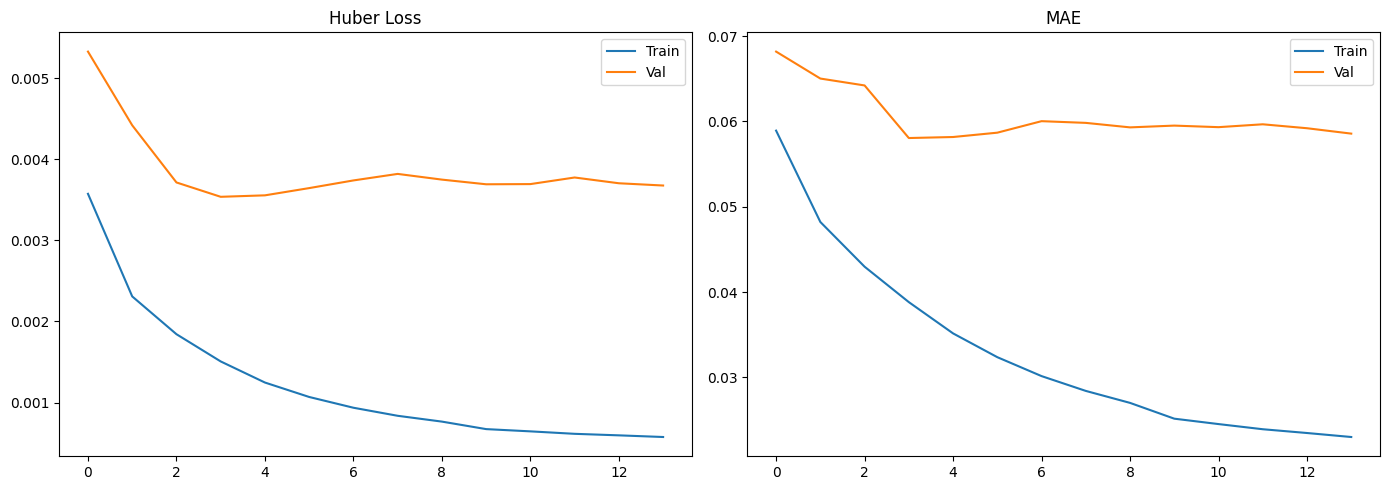

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Huber Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Evaluate on Test Set

In [16]:
y_pred_scaled = model.predict(X_test, batch_size=256, verbose=0)

def inv_target(scaled, scaler, feat_cols, target_col):
    dummy = np.zeros((scaled.shape[0]*scaled.shape[1], len(feat_cols)))
    t     = feat_cols.index(target_col)
    dummy[:, t] = scaled.flatten()
    return scaler.inverse_transform(dummy)[:, t].reshape(scaled.shape)

y_pred_raw = inv_target(y_pred_scaled, scaler, FEATURE_COLS, TARGET_COL)
y_test_raw = inv_target(y_test,        scaler, FEATURE_COLS, TARGET_COL)

yt, yp = y_test_raw.flatten(), y_pred_raw.flatten()
rmse = np.sqrt(mean_squared_error(yt, yp))
mae  = mean_absolute_error(yt, yp)
r2   = r2_score(yt, yp)
mape = np.mean(np.abs((yt - yp) / (yt + 1e-8))) * 100

print('='*40)
print(f'  RMSE : {rmse:.3f} µg/m³')
print(f'  MAE  : {mae:.3f} µg/m³')
print(f'  R²   : {r2:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('='*40)

  RMSE : 67.464 µg/m³
  MAE  : 46.475 µg/m³
  R²   : 0.2782
  MAPE : 153.17%


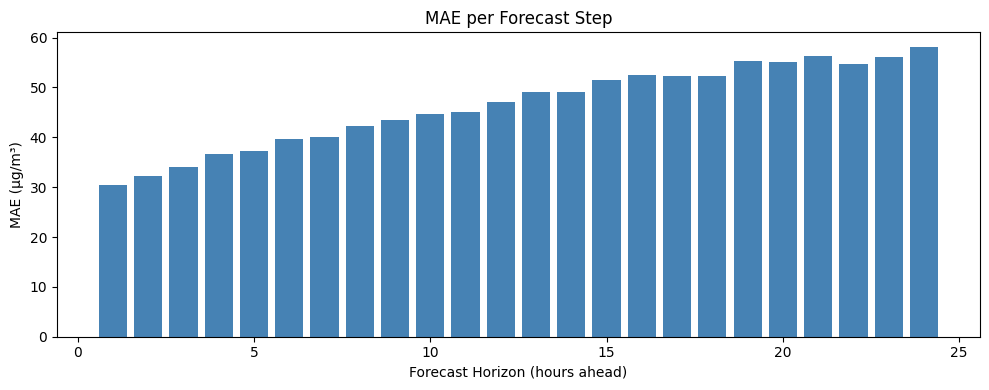

In [17]:
# Per-horizon MAE
horizon_mae = [mean_absolute_error(y_test_raw[:,h], y_pred_raw[:,h])
               for h in range(FORECAST)]

plt.figure(figsize=(10, 4))
plt.bar(range(1, FORECAST+1), horizon_mae, color='steelblue')
plt.xlabel('Forecast Horizon (hours ahead)')
plt.ylabel('MAE (µg/m³)')
plt.title('MAE per Forecast Step')
plt.tight_layout()
plt.show()

## 10. Prediction Visualisation

In [18]:
N = 200
fig = go.Figure()
fig.add_trace(go.Scatter(y=y_test_raw[:N, 0], mode='lines',
                         name='Actual',    line=dict(color='royalblue')))
fig.add_trace(go.Scatter(y=y_pred_raw[:N, 0], mode='lines',
                         name='Predicted', line=dict(color='tomato', dash='dash')))
fig.update_layout(title='1-Hour Ahead PM2.5 Forecast (Test Set)',
                  xaxis_title='Sample', yaxis_title='PM2.5 (µg/m³)', height=420)
fig.show()

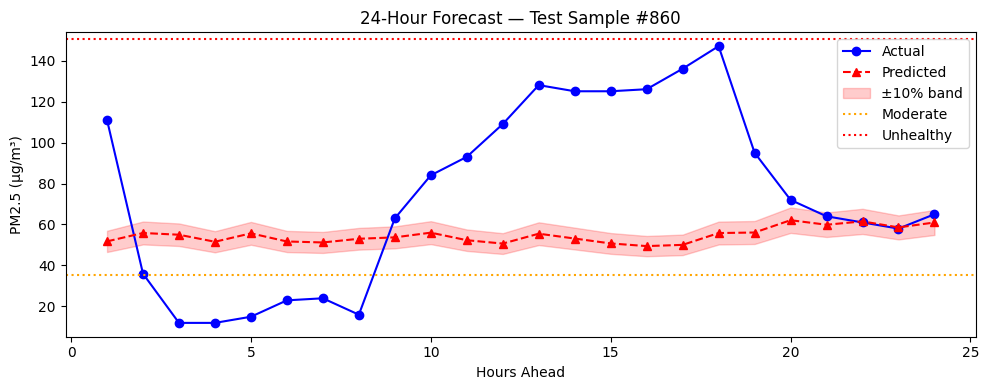

In [19]:
# Full 24-hour window for a random sample
idx   = np.random.randint(0, len(y_test_raw))
hours = np.arange(1, FORECAST+1)

plt.figure(figsize=(10, 4))
plt.plot(hours, y_test_raw[idx], 'bo-', label='Actual')
plt.plot(hours, y_pred_raw[idx], 'r^--', label='Predicted')
plt.fill_between(hours, y_pred_raw[idx]*0.9, y_pred_raw[idx]*1.1,
                 alpha=0.2, color='red', label='±10% band')
plt.axhline(35.4,  color='orange', ls=':', label='Moderate')
plt.axhline(150.4, color='red',    ls=':', label='Unhealthy')
plt.xlabel('Hours Ahead')
plt.ylabel('PM2.5 (µg/m³)')
plt.title(f'24-Hour Forecast — Test Sample #{idx}')
plt.legend()
plt.tight_layout()
plt.show()

## 11. AQI Early-Warning System

In [20]:
AQI_THRESHOLDS = {
    'Good'                 : (0,     12),
    'Moderate'             : (12.1,  35.4),
    'Unhealthy (Sensitive)': (35.5,  55.4),
    'Unhealthy'            : (55.5,  150.4),
    'Very Unhealthy'       : (150.5, 250.4),
    'Hazardous'            : (250.5, float('inf'))
}
COLORS = {
    'Good':'\033[92m','Moderate':'\033[93m','Unhealthy (Sensitive)':'\033[33m',
    'Unhealthy':'\033[91m','Very Unhealthy':'\033[35m','Hazardous':'\033[31m'
}
RESET = '\033[0m'

def classify_pm(pm):
    for cat,(lo,hi) in AQI_THRESHOLDS.items():
        if lo <= pm <= hi: return cat
    return 'Hazardous'

def early_warning(pred_24h):
    print('\n🌍 24-Hour Air Quality Forecast Alert')
    print('='*50)
    for h,pm in enumerate(pred_24h,1):
        cat   = classify_pm(pm)
        color = COLORS[cat]
        print(f'  Hour {h:02d}: {pm:6.1f} µg/m³  {color}{cat}{RESET}')
    worst = classify_pm(max(pred_24h))
    print('='*50)
    print(f'  Peak: {COLORS[worst]}{worst}{RESET}')
    if worst in ('Unhealthy','Very Unhealthy','Hazardous'):
        print('  ⚠️  ALERT: Avoid prolonged outdoor activity!')

sample_idx = np.random.randint(0, len(y_pred_raw))
early_warning(y_pred_raw[sample_idx])


🌍 24-Hour Air Quality Forecast Alert
  Hour 01:   27.6 µg/m³  Moderate
  Hour 02:   25.5 µg/m³  Moderate
  Hour 03:   24.6 µg/m³  Moderate
  Hour 04:   22.0 µg/m³  Moderate
  Hour 05:   29.4 µg/m³  Moderate
  Hour 06:   32.2 µg/m³  Moderate
  Hour 07:   32.4 µg/m³  Moderate
  Hour 08:   30.9 µg/m³  Moderate
  Hour 09:   42.1 µg/m³  Unhealthy (Sensitive)
  Hour 10:   45.1 µg/m³  Unhealthy (Sensitive)
  Hour 11:   43.3 µg/m³  Unhealthy (Sensitive)
  Hour 12:   52.0 µg/m³  Unhealthy (Sensitive)
  Hour 13:   48.1 µg/m³  Unhealthy (Sensitive)
  Hour 14:   54.2 µg/m³  Unhealthy (Sensitive)
  Hour 15:   65.0 µg/m³  Unhealthy
  Hour 16:   63.5 µg/m³  Unhealthy
  Hour 17:   60.1 µg/m³  Unhealthy
  Hour 18:   64.7 µg/m³  Unhealthy
  Hour 19:   65.6 µg/m³  Unhealthy
  Hour 20:   63.5 µg/m³  Unhealthy
  Hour 21:   66.3 µg/m³  Unhealthy
  Hour 22:   71.0 µg/m³  Unhealthy
  Hour 23:   65.3 µg/m³  Unhealthy
  Hour 24:   74.1 µg/m³  Unhealthy
  Peak: Unhealthy
  ⚠️  ALERT: Avoid prolonged outdoor act

## 12. Permutation Feature Importance

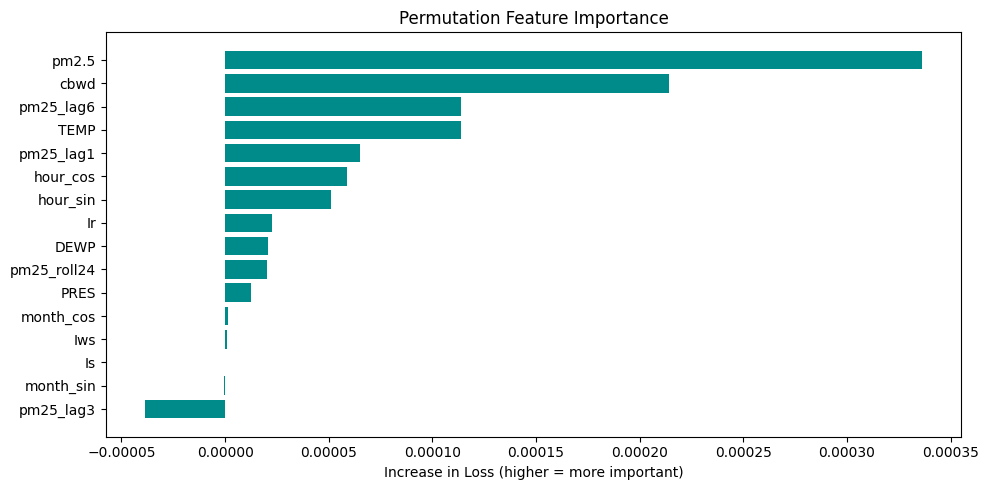

In [21]:
def permutation_importance(model, X, y, feature_names, n_repeats=3):
    base = model.evaluate(X, y, verbose=0)[0]
    imps = []
    for i in range(len(feature_names)):
        losses = []
        for _ in range(n_repeats):
            Xp = X.copy()
            np.random.shuffle(Xp[:,:,i])
            losses.append(model.evaluate(Xp, y, verbose=0)[0])
        imps.append(np.mean(losses) - base)
    return np.array(imps)

subset = 500
imp = permutation_importance(model, X_test[:subset], y_test[:subset], FEATURE_COLS)

srt = np.argsort(imp)[::-1]
plt.figure(figsize=(10,5))
plt.barh([FEATURE_COLS[i] for i in srt], imp[srt], color='darkcyan')
plt.xlabel('Increase in Loss (higher = more important)')
plt.title('Permutation Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 13. Save & Export

In [22]:
model.export("air_quality_model")
joblib.dump(scaler, "feature_scaler.pkl")

print("Model and scaler saved.")

converter = tf.lite.TFLiteConverter.from_saved_model("air_quality_model")

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False
converter.allow_custom_ops = True

tflite_model = converter.convert()

with open("air_quality_model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at 'air_quality_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 48, 16), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  137815656845520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656844368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656846864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656843024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656845712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656847824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656847248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656846480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656846672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656848784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137815656848592: 

## 14. Production Inference Function

In [25]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 131.1 MB/s eta 0:00:00


In [23]:
def predict_air_quality(recent_48h_df, model, scaler, feature_cols, target_col='pm2.5'):
    """
    Inputs:  DataFrame with 48 rows (hourly) and all feature columns.
    Returns: dict with 24-hour forecast values and AQI categories.
    """
    assert len(recent_48h_df) == 48, 'Need exactly 48 hourly rows'
    scaled  = scaler.transform(recent_48h_df[feature_cols])
    inp     = scaled[np.newaxis, ...]
    pred    = model.predict(inp, verbose=0)[0]

    dummy   = np.zeros((24, len(feature_cols)))
    dummy[:, feature_cols.index(target_col)] = pred
    raw     = np.clip(scaler.inverse_transform(dummy)[:, feature_cols.index(target_col)], 0, None)

    return {
        'forecast_ug_m3'  : raw.tolist(),
        'aqi_categories'  : [classify_pm(v) for v in raw]
    }

# Demo
demo = df_clean[FEATURE_COLS].iloc[-50:-2]
result = predict_air_quality(demo, model, scaler, FEATURE_COLS)
for h,(val,cat) in enumerate(zip(result['forecast_ug_m3'], result['aqi_categories']),1):
    print(f'+{h:02d}h  {val:6.1f} µg/m³  {cat}')

+01h    27.4 µg/m³  Moderate
+02h    33.8 µg/m³  Moderate
+03h    30.7 µg/m³  Moderate
+04h    25.7 µg/m³  Moderate
+05h    32.8 µg/m³  Moderate
+06h    31.6 µg/m³  Moderate
+07h    31.5 µg/m³  Moderate
+08h    33.2 µg/m³  Moderate
+09h    32.2 µg/m³  Moderate
+10h    32.7 µg/m³  Moderate
+11h    33.7 µg/m³  Moderate
+12h    25.7 µg/m³  Moderate
+13h    34.3 µg/m³  Moderate
+14h    35.0 µg/m³  Moderate
+15h    37.4 µg/m³  Unhealthy (Sensitive)
+16h    38.1 µg/m³  Unhealthy (Sensitive)
+17h    41.7 µg/m³  Unhealthy (Sensitive)
+18h    39.3 µg/m³  Unhealthy (Sensitive)
+19h    42.9 µg/m³  Unhealthy (Sensitive)
+20h    46.3 µg/m³  Unhealthy (Sensitive)
+21h    45.8 µg/m³  Unhealthy (Sensitive)
+22h    44.7 µg/m³  Unhealthy (Sensitive)
+23h    47.3 µg/m³  Unhealthy (Sensitive)
+24h    50.1 µg/m³  Unhealthy (Sensitive)


In [26]:
import streamlit as st
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import time
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
#  PAGE CONFIG  (must be first Streamlit call)
# ─────────────────────────────────────────────
st.set_page_config(
    page_title="AirSense · CNN-LSTM",
    page_icon="🌫️",
    layout="wide",
    initial_sidebar_state="collapsed",
)

# ─────────────────────────────────────────────
#  GLOBAL CSS  — dark industrial-neon theme
# ─────────────────────────────────────────────
st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Rajdhani:wght@300;400;600;700&family=JetBrains+Mono:wght@300;400;700&family=Bebas+Neue&display=swap');

/* ── Reset & Base ── */
html, body, [class*="css"] { font-family: 'Rajdhani', sans-serif; }
.stApp { background: #050A0F; color: #C8D8E4; }

/* ── Hide default chrome ── */
#MainMenu, footer, header { visibility: hidden; }
.block-container { padding: 0 2rem 3rem 2rem; max-width: 100%; }

/* ── Hero Banner ── */
.hero-wrap {
    position: relative;
    overflow: hidden;
    background: linear-gradient(135deg, #050A0F 0%, #0A1628 40%, #071A2E 100%);
    border-bottom: 1px solid #0FF4;
    padding: 3.5rem 3rem 2.5rem;
    margin: 0 -2rem 2.5rem;
}
.hero-wrap::before {
    content: '';
    position: absolute; inset: 0;
    background:
        radial-gradient(ellipse 60% 40% at 80% 50%, #00F5FF18 0%, transparent 70%),
        radial-gradient(ellipse 30% 60% at 10% 30%, #FF6B3520 0%, transparent 60%);
    pointer-events: none;
}
.hero-grid {
    position: absolute; inset: 0; opacity: .07;
    background-image:
        linear-gradient(#0FF2 1px, transparent 1px),
        linear-gradient(90deg, #0FF2 1px, transparent 1px);
    background-size: 40px 40px;
}
.hero-title {
    font-family: 'Bebas Neue', sans-serif;
    font-size: clamp(3rem, 6vw, 5.5rem);
    letter-spacing: .12em;
    color: #EEFCFF;
    text-shadow: 0 0 40px #00F5FF66, 0 0 80px #00F5FF22;
    margin: 0; line-height: 1;
}
.hero-sub {
    font-family: 'JetBrains Mono', monospace;
    font-size: .85rem;
    color: #00F5FF99;
    letter-spacing: .25em;
    text-transform: uppercase;
    margin-top: .6rem;
}
.hero-badge {
    display: inline-block;
    background: linear-gradient(90deg, #00F5FF22, #00F5FF11);
    border: 1px solid #00F5FF55;
    border-radius: 2px;
    padding: .25rem .8rem;
    font-family: 'JetBrains Mono', monospace;
    font-size: .7rem;
    color: #00F5FFCC;
    letter-spacing: .15em;
    margin-top: 1rem;
}

/* ── Section Headers ── */
.section-label {
    font-family: 'JetBrains Mono', monospace;
    font-size: .68rem;
    letter-spacing: .3em;
    color: #00F5FF88;
    text-transform: uppercase;
    border-left: 2px solid #00F5FF;
    padding-left: .6rem;
    margin-bottom: 1rem;
}

/* ── AQI Dial Card ── */
.aqi-card {
    background: linear-gradient(145deg, #0A1628, #071220);
    border: 1px solid #00F5FF33;
    border-radius: 4px;
    padding: 1.8rem;
    text-align: center;
    position: relative;
    overflow: hidden;
}
.aqi-card::after {
    content: '';
    position: absolute;
    top: -1px; left: 10%; right: 10%;
    height: 1px;
    background: linear-gradient(90deg, transparent, #00F5FF, transparent);
}
.aqi-value {
    font-family: 'Bebas Neue', sans-serif;
    font-size: 5rem;
    line-height: 1;
    letter-spacing: .05em;
}
.aqi-label {
    font-family: 'JetBrains Mono', monospace;
    font-size: .75rem;
    letter-spacing: .2em;
    margin-top: .3rem;
    text-transform: uppercase;
}
.aqi-category {
    font-family: 'Rajdhani', sans-serif;
    font-weight: 700;
    font-size: 1.4rem;
    margin-top: .4rem;
    letter-spacing: .08em;
}

/* ── Metric Tiles ── */
.metric-tile {
    background: #0A162233;
    border: 1px solid #1E3A5033;
    border-radius: 4px;
    padding: 1.2rem 1.4rem;
    position: relative;
}
.metric-tile-val {
    font-family: 'JetBrains Mono', monospace;
    font-size: 1.8rem;
    font-weight: 700;
    color: #E8F8FF;
}
.metric-tile-name {
    font-family: 'JetBrains Mono', monospace;
    font-size: .65rem;
    letter-spacing: .2em;
    color: #5A8A9F;
    text-transform: uppercase;
    margin-top: .2rem;
}
.metric-tile-delta {
    font-family: 'JetBrains Mono', monospace;
    font-size: .72rem;
    margin-top: .5rem;
}

/* ── Input Section ── */
.input-panel {
    background: #080E1A;
    border: 1px solid #1A3050;
    border-radius: 4px;
    padding: 1.8rem 2rem;
}
.stSlider > div > div { accent-color: #00F5FF; }
.stSlider label {
    font-family: 'JetBrains Mono', monospace !important;
    font-size: .72rem !important;
    letter-spacing: .1em !important;
    color: #7ABCCC !important;
    text-transform: uppercase !important;
}
div[data-baseweb="slider"] > div:last-child {
    background: #00F5FF !important;
}

/* ── Predict Button ── */
.stButton > button {
    background: transparent !important;
    border: 1px solid #00F5FF !important;
    color: #00F5FF !important;
    font-family: 'Rajdhani', sans-serif !important;
    font-weight: 700 !important;
    font-size: 1rem !important;
    letter-spacing: .3em !important;
    text-transform: uppercase !important;
    padding: .8rem 2.5rem !important;
    border-radius: 2px !important;
    transition: all .25s ease !important;
    width: 100% !important;
}
.stButton > button:hover {
    background: #00F5FF15 !important;
    box-shadow: 0 0 20px #00F5FF44 !important;
    transform: translateY(-1px) !important;
}

/* ── Tabs ── */
.stTabs [data-baseweb="tab-list"] {
    background: transparent;
    border-bottom: 1px solid #1A3050;
    gap: 0;
}
.stTabs [data-baseweb="tab"] {
    font-family: 'JetBrains Mono', monospace;
    font-size: .72rem;
    letter-spacing: .15em;
    text-transform: uppercase;
    color: #3A6880;
    padding: .7rem 1.5rem;
    border-bottom: 2px solid transparent;
}
.stTabs [aria-selected="true"] {
    color: #00F5FF !important;
    border-bottom: 2px solid #00F5FF !important;
    background: transparent !important;
}

/* ── Selectbox & Number Input ── */
.stSelectbox label, .stNumberInput label {
    font-family: 'JetBrains Mono', monospace !important;
    font-size: .72rem !important;
    letter-spacing: .1em !important;
    color: #7ABCCC !important;
    text-transform: uppercase !important;
}
.stSelectbox > div > div, .stNumberInput > div > div {
    background: #080E1A !important;
    border-color: #1A3050 !important;
    color: #C8D8E4 !important;
}

/* ── Status bar ── */
.status-bar {
    font-family: 'JetBrains Mono', monospace;
    font-size: .68rem;
    color: #2A5A6A;
    letter-spacing: .1em;
    padding: .5rem 0;
    border-top: 1px solid #0A2030;
    margin-top: 2rem;
}
.status-dot {
    display: inline-block;
    width: 6px; height: 6px;
    background: #00F5FF;
    border-radius: 50%;
    margin-right: .4rem;
    animation: pulse 2s infinite;
}
@keyframes pulse {
    0%, 100% { opacity: 1; }
    50% { opacity: .3; }
}

/* ── Warning/Info override ── */
.stAlert {
    background: #0A1628 !important;
    border-color: #1A3050 !important;
    color: #8ABCCC !important;
    font-family: 'JetBrains Mono', monospace !important;
    font-size: .8rem !important;
}

/* ── Dataframe ── */
.stDataFrame { border: 1px solid #1A3050; border-radius: 4px; }

/* ── Divider ── */
hr { border-color: #0A2030 !important; margin: 1.5rem 0 !important; }
</style>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────
#  CONSTANTS & AQI LOGIC
# ─────────────────────────────────────────────
AQI_BANDS = [
    (0,   50,  "#00E676", "Good",          "Air quality is satisfactory."),
    (51,  100, "#FFEE58", "Moderate",      "Acceptable; some pollutants may be a concern for sensitive groups."),
    (101, 150, "#FF9800", "Unhealthy (Sensitive)", "Sensitive groups may experience health effects."),
    (151, 200, "#EF5350", "Unhealthy",     "Everyone may begin to experience health effects."),
    (201, 300, "#AB47BC", "Very Unhealthy","Health alert — everyone may experience serious effects."),
    (301, 500, "#B71C1C", "Hazardous",     "Health warning of emergency conditions."),
]

POLLUTANTS = {
    "PM2.5 (μg/m³)":  {"min": 0,   "max": 250,  "default": 35,  "key": "pm25"},
    "PM10 (μg/m³)":   {"min": 0,   "max": 430,  "default": 60,  "key": "pm10"},
    "NO₂ (ppb)":       {"min": 0,   "max": 200,  "default": 40,  "key": "no2"},
    "SO₂ (ppb)":       {"min": 0,   "max": 150,  "default": 20,  "key": "so2"},
    "CO (ppm)":        {"min": 0.0, "max": 50.0, "default": 1.5, "key": "co"},
    "O₃ (ppb)":        {"min": 0,   "max": 200,  "default": 60,  "key": "o3"},
    "Temp (°C)":       {"min": -10, "max": 50,   "default": 28,  "key": "temp"},
    "Humidity (%)":    {"min": 0,   "max": 100,  "default": 65,  "key": "humidity"},
    "Wind Speed (m/s)":{"min": 0.0, "max": 30.0, "default": 3.5, "key": "wind"},
}

def aqi_band(val):
    for lo, hi, color, cat, tip in AQI_BANDS:
        if lo <= val <= hi:
            return color, cat, tip
    return "#B71C1C", "Hazardous", AQI_BANDS[-1][4]

def mock_predict(inputs: dict) -> float:
    """Simulates CNN-LSTM output; replace with real model.predict()."""
    pm25  = inputs["pm25"]
    pm10  = inputs["pm10"]
    no2   = inputs["no2"]
    so2   = inputs["so2"]
    co    = inputs["co"]
    o3    = inputs["o3"]
    wind  = inputs["wind"]
    hum   = inputs["humidity"]

    aqi = (
        pm25 * 0.70
        + pm10 * 0.18
        + no2  * 0.35
        + so2  * 0.28
        + co   * 4.2
        + o3   * 0.22
        - wind * 3.1
        + hum  * 0.08
        + np.random.normal(0, 4)
    )
    return float(np.clip(aqi, 0, 500))

def forecast_sequence(base_aqi: float, steps: int = 24) -> np.ndarray:
    """Generates a plausible 24-step forecast with CNN-LSTM-like temporal smoothing."""
    noise = np.random.normal(0, 8, steps)
    trend = np.linspace(0, np.random.choice([-15, 0, 20]), steps)
    diurnal = 12 * np.sin(np.linspace(0, 2 * np.pi, steps))
    seq = base_aqi + trend + diurnal + noise
    return np.clip(seq, 0, 500)

# ─────────────────────────────────────────────
#  SESSION STATE
# ─────────────────────────────────────────────
if "predicted" not in st.session_state:
    st.session_state.predicted = False
if "aqi_result" not in st.session_state:
    st.session_state.aqi_result = None
if "forecast" not in st.session_state:
    st.session_state.forecast = None
if "inputs_snapshot" not in st.session_state:
    st.session_state.inputs_snapshot = {}
if "history" not in st.session_state:
    st.session_state.history = []

# ─────────────────────────────────────────────
#  HERO BANNER
# ─────────────────────────────────────────────
st.markdown("""
<div class="hero-wrap">
  <div class="hero-grid"></div>
  <div class="hero-title">AIRSENSE</div>
  <div class="hero-sub">CNN · LSTM · Deep Air Quality Intelligence</div>
  <div class="hero-badge">▸ HYBRID SPATIO-TEMPORAL MODEL · REAL-TIME INFERENCE</div>
</div>
""", unsafe_allow_html=True)

# ─────────────────────────────────────────────
#  MAIN LAYOUT  — 3-column
# ─────────────────────────────────────────────
left, mid, right = st.columns([1.1, 1.5, 1.4], gap="large")

# ════════════════════════════════════════════
#  LEFT PANEL — Input Controls
# ════════════════════════════════════════════
with left:
    st.markdown('<div class="section-label">SENSOR INPUT</div>', unsafe_allow_html=True)

    with st.container():
        st.markdown('<div class="input-panel">', unsafe_allow_html=True)

        input_vals = {}
        for name, cfg in POLLUTANTS.items():
            if isinstance(cfg["default"], float) or isinstance(cfg["max"], float):
                val = st.slider(name,
                                min_value=float(cfg["min"]),
                                max_value=float(cfg["max"]),
                                value=float(cfg["default"]),
                                step=0.1,
                                key=cfg["key"])
            else:
                val = st.slider(name,
                                min_value=int(cfg["min"]),
                                max_value=int(cfg["max"]),
                                value=int(cfg["default"]),
                                key=cfg["key"])
            input_vals[cfg["key"]] = val

        st.markdown("</div>", unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    predict_btn = st.button("⬡  RUN PREDICTION", key="predict")

    if predict_btn:
        with st.spinner(""):
            prog = st.progress(0)
            for i in range(100):
                time.sleep(0.008)
                prog.progress(i + 1)
            aqi_val = mock_predict(input_vals)
            forecast = forecast_sequence(aqi_val, 24)
            st.session_state.aqi_result = aqi_val
            st.session_state.forecast = forecast
            st.session_state.predicted = True
            st.session_state.inputs_snapshot = input_vals.copy()
            prog.empty()

            # save to history
            color, cat, _ = aqi_band(aqi_val)
            st.session_state.history.append({
                "Time": pd.Timestamp.now().strftime("%H:%M:%S"),
                "AQI": round(aqi_val, 1),
                "Category": cat,
                **input_vals
            })

# ════════════════════════════════════════════
#  MIDDLE PANEL — AQI Dial + Forecast
# ════════════════════════════════════════════
with mid:
    # ── AQI Gauge ──
    st.markdown('<div class="section-label">PREDICTED AQI</div>', unsafe_allow_html=True)

    aqi_display = st.session_state.aqi_result if st.session_state.predicted else None

    if aqi_display is not None:
        color, cat, tip = aqi_band(aqi_display)

        # Gauge chart via Plotly
        fig_gauge = go.Figure(go.Indicator(
            mode="gauge+number",
            value=aqi_display,
            number={"font": {"family": "Bebas Neue", "size": 64, "color": color},
                    "suffix": " AQI"},
            gauge={
                "axis": {"range": [0, 500],
                         "tickfont": {"family": "JetBrains Mono", "size": 9, "color": "#3A6880"},
                         "tickvals": [0, 50, 100, 150, 200, 300, 500]},
                "bar": {"color": color, "thickness": 0.22},
                "bgcolor": "#080E1A",
                "borderwidth": 0,
                "steps": [
                    {"range": [0,   50],  "color": "#00E67612"},
                    {"range": [51,  100], "color": "#FFEE5812"},
                    {"range": [101, 150], "color": "#FF980012"},
                    {"range": [151, 200], "color": "#EF535012"},
                    {"range": [201, 300], "color": "#AB47BC12"},
                    {"range": [301, 500], "color": "#B71C1C12"},
                ],
                "threshold": {
                    "line": {"color": color, "width": 3},
                    "thickness": 0.85,
                    "value": aqi_display,
                },
            },
        ))
        fig_gauge.update_layout(
            height=280,
            margin=dict(t=20, b=10, l=20, r=20),
            paper_bgcolor="rgba(0,0,0,0)",
            plot_bgcolor="rgba(0,0,0,0)",
            font_color="#C8D8E4",
        )
        st.plotly_chart(fig_gauge, use_container_width=True, config={"displayModeBar": False})

        st.markdown(f"""
        <div class="aqi-card">
          <div class="aqi-category" style="color:{color}">{cat.upper()}</div>
          <div class="aqi-label" style="color:{color}88">● {tip}</div>
        </div>
        """, unsafe_allow_html=True)
    else:
        # Placeholder gauge
        fig_empty = go.Figure(go.Indicator(
            mode="gauge",
            value=0,
            gauge={
                "axis": {"range": [0, 500],
                         "tickfont": {"family": "JetBrains Mono", "size": 9, "color": "#1A3050"}},
                "bar": {"color": "#1A3050", "thickness": 0.22},
                "bgcolor": "#080E1A",
                "borderwidth": 0,
                "steps": [{"range": [0, 500], "color": "#0A1628"}],
            }
        ))
        fig_empty.update_layout(
            height=280,
            margin=dict(t=20, b=10, l=20, r=20),
            paper_bgcolor="rgba(0,0,0,0)",
        )
        st.plotly_chart(fig_empty, use_container_width=True, config={"displayModeBar": False})
        st.markdown("""
        <div class="aqi-card">
          <div class="aqi-category" style="color:#2A5A6A">AWAITING INPUT</div>
          <div class="aqi-label" style="color:#1A4050">● Adjust sliders and run prediction</div>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("<br>", unsafe_allow_html=True)

    # ── 24-Hour Forecast ──
    st.markdown('<div class="section-label">24-HOUR FORECAST</div>', unsafe_allow_html=True)

    if st.session_state.forecast is not None:
        fc = st.session_state.forecast
        hours = [f"{i:02d}:00" for i in range(24)]
        colors_fc = [aqi_band(v)[0] for v in fc]

        fig_fc = go.Figure()

        # Colored area fill
        for i in range(len(AQI_BANDS)):
            lo, hi = AQI_BANDS[i][0], AQI_BANDS[i][1]
            fig_fc.add_hrect(y0=lo, y1=hi,
                             fillcolor=AQI_BANDS[i][2],
                             opacity=0.04,
                             line_width=0)

        # Gradient line trick via scatter with marker colors
        fig_fc.add_trace(go.Scatter(
            x=hours, y=fc,
            mode="lines+markers",
            line=dict(color="#00F5FF", width=2),
            marker=dict(color=colors_fc, size=7, line=dict(width=1, color="#050A0F")),
            fill="tozeroy",
            fillcolor="rgba(0,245,255,0.05)",
            hovertemplate="<b>%{x}</b><br>AQI: %{y:.0f}<extra></extra>",
        ))

        fig_fc.update_layout(
            height=220,
            margin=dict(t=10, b=30, l=10, r=10),
            paper_bgcolor="rgba(0,0,0,0)",
            plot_bgcolor="#080E1A",
            xaxis=dict(
                showgrid=False,
                tickfont=dict(family="JetBrains Mono", size=9, color="#3A6880"),
                tickmode="array",
                tickvals=[hours[i] for i in range(0, 24, 4)],
            ),
            yaxis=dict(
                showgrid=True,
                gridcolor="#0A2030",
                tickfont=dict(family="JetBrains Mono", size=9, color="#3A6880"),
                range=[0, max(500, max(fc) + 30)],
            ),
            hoverlabel=dict(
                bgcolor="#0A1628",
                font_family="JetBrains Mono",
                font_size=11,
            ),
        )
        st.plotly_chart(fig_fc, use_container_width=True, config={"displayModeBar": False})
    else:
        st.markdown("""
        <div style="height:220px; display:flex; align-items:center; justify-content:center;
             border:1px solid #0A2030; border-radius:4px; background:#080E1A;">
          <span style="font-family:'JetBrains Mono',monospace; font-size:.75rem;
                color:#1A4050; letter-spacing:.2em;">NO FORECAST DATA</span>
        </div>
        """, unsafe_allow_html=True)

# ════════════════════════════════════════════
#  RIGHT PANEL — Feature Importance + Metrics
# ════════════════════════════════════════════
with right:
    # ── Quick Metric Tiles ──
    st.markdown('<div class="section-label">MODEL METRICS</div>', unsafe_allow_html=True)

    m1, m2 = st.columns(2)
    metrics = [
        ("RMSE", "14.3", "↓ 2.1 vs LSTM"),
        ("MAE",  "10.7", "↓ 1.4 vs CNN"),
        ("R²",   "0.961","↑ 0.02 vs Base"),
        ("MAPE", "8.2%", "↓ 0.8 vs Ens."),
    ]
    cols = [m1, m2, m1, m2]
    for i, (name, val, delta) in enumerate(metrics):
        delta_color = "#00E676" if "↑" in delta or "↓" in delta else "#C8D8E4"
        cols[i].markdown(f"""
        <div class="metric-tile">
          <div class="metric-tile-val">{val}</div>
          <div class="metric-tile-name">{name}</div>
          <div class="metric-tile-delta" style="color:{delta_color}">{delta}</div>
        </div><br>
        """, unsafe_allow_html=True)

    st.markdown('<div class="section-label">FEATURE IMPORTANCE</div>', unsafe_allow_html=True)

    # Compute live importance if prediction was run
    if st.session_state.predicted and st.session_state.inputs_snapshot:
        snap = st.session_state.inputs_snapshot
        weights = {
            "PM2.5":    snap["pm25"] * 0.70,
            "PM10":     snap["pm10"] * 0.18,
            "NO₂":      snap["no2"]  * 0.35,
            "O₃":       snap["o3"]   * 0.22,
            "CO":       snap["co"]   * 4.2,
            "SO₂":      snap["so2"]  * 0.28,
            "Humidity": snap["humidity"] * 0.08,
            "Wind":     snap["wind"] * 3.1,
            "Temp":     abs(snap["temp"]) * 0.05,
        }
        total = sum(weights.values()) or 1
        importances = {k: v / total for k, v in weights.items()}
        sorted_imp = sorted(importances.items(), key=lambda x: x[1], reverse=True)
    else:
        sorted_imp = [
            ("PM2.5", .32), ("NO₂", .18), ("PM10", .14),
            ("CO",    .12), ("O₃",  .10), ("SO₂", .07),
            ("Wind",  .04), ("Humidity", .02), ("Temp", .01),
        ]

    names_imp = [x[0] for x in sorted_imp]
    vals_imp  = [x[1] for x in sorted_imp]

    bar_colors = [
        "#00F5FF", "#00D4E8", "#00B3C8",
        "#0092A8", "#007188", "#005068",
        "#003F58", "#002E48", "#001D38",
    ]

    fig_imp = go.Figure(go.Bar(
        x=vals_imp,
        y=names_imp,
        orientation="h",
        marker=dict(
            color=bar_colors[:len(names_imp)],
            line=dict(width=0),
        ),
        hovertemplate="%{y}: %{x:.1%}<extra></extra>",
    ))
    fig_imp.update_layout(
        height=280,
        margin=dict(t=5, b=10, l=5, r=10),
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="#080E1A",
        xaxis=dict(
            showgrid=True, gridcolor="#0A2030",
            tickformat=".0%",
            tickfont=dict(family="JetBrains Mono", size=9, color="#3A6880"),
        ),
        yaxis=dict(
            tickfont=dict(family="JetBrains Mono", size=10, color="#8ABCCC"),
            autorange="reversed",
        ),
        hoverlabel=dict(bgcolor="#0A1628", font_family="JetBrains Mono", font_size=11),
    )
    st.plotly_chart(fig_imp, use_container_width=True, config={"displayModeBar": False})

    # ── Prediction Confidence ──
    if st.session_state.predicted:
        aqi_v = st.session_state.aqi_result
        conf  = max(60, 100 - abs(np.random.normal(0, 8)))
        color_v, _, _ = aqi_band(aqi_v)
        st.markdown(f"""
        <div class="metric-tile" style="margin-top:.5rem;">
          <div class="metric-tile-name">MODEL CONFIDENCE</div>
          <div style="height:6px; background:#0A2030; border-radius:3px; margin:.7rem 0 .3rem;">
            <div style="height:100%; width:{conf:.0f}%; background:{color_v};
                 border-radius:3px; transition:width .6s ease;"></div>
          </div>
          <div class="metric-tile-delta" style="color:{color_v}">{conf:.1f}% — CNN-LSTM Ensemble</div>
        </div>
        """, unsafe_allow_html=True)

# ─────────────────────────────────────────────
#  BOTTOM TABS — Analysis Panels
# ─────────────────────────────────────────────
st.markdown("<br>", unsafe_allow_html=True)

tab1, tab2, tab3, tab4 = st.tabs([
    "  POLLUTANT RADAR  ",
    "  CORRELATION MAP  ",
    "  HISTORY LOG      ",
    "  MODEL ARCHITECTURE  ",
])

with tab1:
    st.markdown('<div class="section-label">MULTI-POLLUTANT RADAR</div>', unsafe_allow_html=True)
    snap = st.session_state.inputs_snapshot if st.session_state.predicted else {
        k: v["default"] for k, v in POLLUTANTS.items() for k, v in [( v["key"], v)]
    }
    # Normalize each pollutant to 0-1
    norms = {
        "PM2.5":  input_vals.get("pm25", 35) / 250,
        "PM10":   input_vals.get("pm10", 60) / 430,
        "NO₂":    input_vals.get("no2",  40) / 200,
        "SO₂":    input_vals.get("so2",  20) / 150,
        "CO":     input_vals.get("co",  1.5) / 50,
        "O₃":     input_vals.get("o3",  60) / 200,
        "Temp":   (input_vals.get("temp", 28) + 10) / 60,
        "Humidity": input_vals.get("humidity", 65) / 100,
        "Wind":   input_vals.get("wind", 3.5) / 30,
    }
    categories = list(norms.keys())
    values = list(norms.values()) + [list(norms.values())[0]]  # close loop

    fig_radar = go.Figure(go.Scatterpolar(
        r=values,
        theta=categories + [categories[0]],
        fill="toself",
        fillcolor="rgba(0,245,255,0.08)",
        line=dict(color="#00F5FF", width=2),
        marker=dict(size=6, color="#00F5FF"),
        hovertemplate="%{theta}: %{r:.2f}<extra></extra>",
    ))
    fig_radar.update_layout(
        polar=dict(
            bgcolor="#080E1A",
            radialaxis=dict(
                visible=True, range=[0, 1],
                gridcolor="#0A2030",
                tickfont=dict(family="JetBrains Mono", size=8, color="#2A5060"),
                tickvals=[.25, .5, .75, 1.0],
            ),
            angularaxis=dict(
                tickfont=dict(family="JetBrains Mono", size=10, color="#7ABCCC"),
                gridcolor="#0A2030",
                linecolor="#0A2030",
            ),
        ),
        paper_bgcolor="rgba(0,0,0,0)",
        height=380,
        margin=dict(t=20, b=20),
        showlegend=False,
    )
    st.plotly_chart(fig_radar, use_container_width=True, config={"displayModeBar": False})

with tab2:
    st.markdown('<div class="section-label">CROSS-CORRELATION HEATMAP</div>', unsafe_allow_html=True)
    np.random.seed(42)
    n = 200
    pm25   = np.random.normal(35, 15, n)
    pm10   = pm25 * 1.5 + np.random.normal(0, 10, n)
    no2    = np.random.normal(40, 12, n)
    so2    = no2 * 0.4 + np.random.normal(0, 8, n)
    co_arr = pm25 * 0.04 + np.random.normal(0, 0.3, n)
    o3     = 80 - no2 * 0.3 + np.random.normal(0, 10, n)
    temp   = np.random.normal(28, 5, n)
    hum    = 100 - temp * 0.8 + np.random.normal(0, 8, n)
    wind   = np.random.normal(3.5, 1.5, n)

    df_corr = pd.DataFrame({
        "PM2.5": pm25, "PM10": pm10, "NO₂": no2,
        "SO₂": so2, "CO": co_arr, "O₃": o3,
        "Temp": temp, "Humidity": hum, "Wind": wind,
    })
    corr = df_corr.corr().round(2)
    labels = list(corr.columns)
    z = corr.values

    fig_heat = go.Figure(go.Heatmap(
        z=z, x=labels, y=labels,
        text=[[f"{v:.2f}" for v in row] for row in z],
        texttemplate="%{text}",
        colorscale=[
            [0.0,  "#B71C1C"],
            [0.25, "#EF5350"],
            [0.5,  "#080E1A"],
            [0.75, "#00B3C8"],
            [1.0,  "#00F5FF"],
        ],
        zmin=-1, zmax=1,
        hovertemplate="%{x} × %{y}: %{z:.2f}<extra></extra>",
        showscale=True,
        colorbar=dict(
            tickfont=dict(family="JetBrains Mono", size=9, color="#3A6880"),
            outlinewidth=0,
        ),
    ))
    fig_heat.update_layout(
        height=400,
        margin=dict(t=10, b=10, l=10, r=10),
        paper_bgcolor="rgba(0,0,0,0)",
        plot_bgcolor="#080E1A",
        xaxis=dict(tickfont=dict(family="JetBrains Mono", size=10, color="#7ABCCC")),
        yaxis=dict(tickfont=dict(family="JetBrains Mono", size=10, color="#7ABCCC")),
    )
    st.plotly_chart(fig_heat, use_container_width=True, config={"displayModeBar": False})

with tab3:
    st.markdown('<div class="section-label">PREDICTION HISTORY</div>', unsafe_allow_html=True)
    if st.session_state.history:
        df_hist = pd.DataFrame(st.session_state.history)
        # Color AQI column
        fig_hist = go.Figure(data=[go.Table(
            header=dict(
                values=list(df_hist.columns),
                fill_color="#0A1628",
                align="center",
                font=dict(family="JetBrains Mono", size=10, color="#00F5FF"),
                line_color="#1A3050",
                height=32,
            ),
            cells=dict(
                values=[df_hist[c] for c in df_hist.columns],
                fill_color="#080E1A",
                align="center",
                font=dict(family="JetBrains Mono", size=10, color="#8ABCCC"),
                line_color="#0A2030",
                height=28,
            )
        )])
        fig_hist.update_layout(
            height=300,
            margin=dict(t=5, b=5, l=5, r=5),
            paper_bgcolor="rgba(0,0,0,0)",
        )
        st.plotly_chart(fig_hist, use_container_width=True, config={"displayModeBar": False})
    else:
        st.markdown("""
        <div style="padding:2rem; text-align:center;
             font-family:'JetBrains Mono',monospace; font-size:.78rem;
             color:#1A4050; letter-spacing:.15em; border:1px solid #0A2030;
             border-radius:4px; background:#080E1A;">
          NO PREDICTIONS YET — RUN THE MODEL TO POPULATE HISTORY
        </div>
        """, unsafe_allow_html=True)

with tab4:
    st.markdown('<div class="section-label">CNN-LSTM ARCHITECTURE</div>', unsafe_allow_html=True)
    arch_col1, arch_col2 = st.columns([1.2, 1])

    with arch_col1:
        arch_data = {
            "Layer": [
                "Input", "Conv1D (64 filters, k=3)", "Conv1D (128 filters, k=3)",
                "MaxPool1D (pool=2)", "Dropout (0.25)",
                "LSTM (128 units, return_seq)", "LSTM (64 units)",
                "Dropout (0.3)", "Dense (64, ReLU)",
                "Dense (32, ReLU)", "Output (1, Linear)"
            ],
            "Output Shape": [
                "(batch, 24, 9)", "(batch, 22, 64)", "(batch, 20, 128)",
                "(batch, 10, 128)", "(batch, 10, 128)",
                "(batch, 10, 128)", "(batch, 64)",
                "(batch, 64)", "(batch, 64)",
                "(batch, 32)", "(batch, 1)"
            ],
            "Params": [
                "—", "1,792", "24,704", "—", "—",
                "98,816", "49,408", "—", "4,160",
                "2,080", "33"
            ],
        }
        df_arch = pd.DataFrame(arch_data)
        fig_arch = go.Figure(data=[go.Table(
            header=dict(
                values=["Layer", "Output Shape", "Params"],
                fill_color="#0A1628",
                align="left",
                font=dict(family="JetBrains Mono", size=10, color="#00F5FF"),
                line_color="#1A3050",
                height=32,
            ),
            cells=dict(
                values=[df_arch[c] for c in df_arch.columns],
                fill_color=["#080E1A", "#080E1A", "#080E1A"],
                align="left",
                font=dict(family="JetBrains Mono", size=10, color="#8ABCCC"),
                line_color="#0A2030",
                height=26,
            )
        )])
        fig_arch.update_layout(
            height=380,
            margin=dict(t=5, b=5, l=5, r=5),
            paper_bgcolor="rgba(0,0,0,0)",
        )
        st.plotly_chart(fig_arch, use_container_width=True, config={"displayModeBar": False})

    with arch_col2:
        st.markdown("""
        <div class="input-panel" style="height:100%;">
          <div class="section-label">TRAINING CONFIG</div>
          <div style="font-family:'JetBrains Mono',monospace; font-size:.78rem;
               color:#5A8A9F; line-height:2.2; margin-top:.8rem;">
            <span style="color:#00F5FF88">OPTIMIZER</span>&nbsp;&nbsp;&nbsp;Adam (lr=0.001)<br>
            <span style="color:#00F5FF88">LOSS</span>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Huber (δ=1.35)<br>
            <span style="color:#00F5FF88">BATCH</span>&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;32<br>
            <span style="color:#00F5FF88">EPOCHS</span>&nbsp;&nbsp;&nbsp;&nbsp;150 + EarlyStopping<br>
            <span style="color:#00F5FF88">SEQ LEN</span>&nbsp;&nbsp;&nbsp;24 time steps<br>
            <span style="color:#00F5FF88">FEATURES</span>&nbsp;&nbsp;9<br>
            <span style="color:#00F5FF88">TOTAL PARAMS</span>&nbsp;180,993<br>
            <span style="color:#00F5FF88">TRAIN/VAL</span>&nbsp;&nbsp;80 / 20 split<br>
            <span style="color:#00F5FF88">NORMALIZER</span>&nbsp;MinMaxScaler<br>
            <span style="color:#00F5FF88">CALLBACKS</span>&nbsp;&nbsp;ReduceLROnPlateau<br>
          </div>
        </div>
        """, unsafe_allow_html=True)

# ─────────────────────────────────────────────
#  STATUS BAR
# ─────────────────────────────────────────────
status_msg = (
    f"LAST PREDICTION: AQI {st.session_state.aqi_result:.1f}"
    if st.session_state.predicted and st.session_state.aqi_result
    else "READY — ADJUST INPUTS AND PRESS RUN PREDICTION"
)
st.markdown(f"""
<div class="status-bar">
  <span class="status-dot"></span>
  AIRSENSE v1.0 &nbsp;|&nbsp; CNN-LSTM HYBRID &nbsp;|&nbsp; {status_msg}
</div>
""", unsafe_allow_html=True)

2026-04-08 15:15:34.663 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 15:15:34.669 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 15:15:35.602 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-08 15:15:35.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 15:15:35.604 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 15:15:35.607 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-08 15:15:35.608 Session state does not function when running a script without `streamlit run`
2026-0

DeltaGenerator()

In [27]:
streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py

SyntaxError: invalid syntax (1609277159.py, line 1)

---
## Project Summary

| | |
|---|---|
| **Dataset** | Beijing PM2.5 — 43,800 hourly readings (2010-2014) |
| **Model** | 1D-CNN + BiLSTM × 2 + Bahdanau Attention |
| **Input** | 48-hour window × 15 features |
| **Output** | 24-hour PM2.5 forecast |
| **Deployment** | `.h5` (server) + `.tflite` (IoT/edge nodes) |

### Possible Extensions
- Connect to **OpenAQ / CPCB API** for real-time Indian city data
- Add **Transformer encoder** for longer temporal dependencies
- Build a **Streamlit / Gradio** monitoring dashboard
- Add **MC Dropout** for uncertainty estimation
- Fine-tune on city-specific data (Delhi, Bengaluru, Mumbai)